In [1]:
import os
import zipfile
import pandas as pd

raw_dir = r"D:\Study Abroad\course\DSCI498\Project\data\raw"
out_root = r"D:\Study Abroad\course\DSCI498\Project\data\extracted"

audio_dir = os.path.join(out_root, "audio")
osu_dir = os.path.join(out_root, "osu")
os.makedirs(audio_dir, exist_ok=True)
os.makedirs(osu_dir, exist_ok=True)

rows = []

def parse_osu_metadata(text: str):
    mode = None
    audio_filename = None

    for line in text.splitlines():
        line = line.strip()
        if line.startswith("Mode:"):
            mode = line.split(":", 1)[1].strip()
        elif line.startswith("AudioFilename:"):
            audio_filename = line.split(":", 1)[1].strip()

    return mode, audio_filename


def safe_basename(path_str: str) -> str:
    return os.path.basename(path_str.replace("\\", "/"))


for fname in os.listdir(raw_dir):
    if not fname.lower().endswith(".osz"):
        continue

    osz_path = os.path.join(raw_dir, fname)
    osz_id = os.path.splitext(fname)[0]

    try:
        with zipfile.ZipFile(osz_path, "r") as z:
            members = z.namelist()
            member_lookup = {m.lower(): m for m in members}

            # 找出所有 taiko osu
            taiko_maps = []

            for member in members:
                if not member.lower().endswith(".osu"):
                    continue

                try:
                    with z.open(member) as f:
                        text = f.read().decode("utf-8", errors="replace")
                except Exception:
                    continue

                mode, audio_filename = parse_osu_metadata(text)

                if mode == "1":   # Taiko
                    taiko_maps.append({
                        "member": member,
                        "text": text,
                        "audio_filename": audio_filename
                    })

            if not taiko_maps:
                continue

            # 同一个 osz 可能多个 taiko 谱面
            for idx, item in enumerate(taiko_maps):
                osu_member = item["member"]
                text = item["text"]
                audio_filename = item["audio_filename"]

                if not audio_filename:
                    print(f"[WARN] {fname} / {osu_member} has no AudioFilename")
                    continue

                # 兼容路径大小写
                audio_member = None
                if audio_filename in members:
                    audio_member = audio_filename
                else:
                    audio_member = member_lookup.get(audio_filename.lower())

                if audio_member is None:
                    print(f"[WARN] Missing audio in {fname}: {audio_filename}")
                    continue

                audio_ext = os.path.splitext(audio_member)[1].lower()
                if audio_ext not in [".mp3", ".wav", ".ogg"]:
                    print(f"[WARN] Unsupported audio type in {fname}: {audio_member}")
                    continue

                # 输出文件名
                audio_out_name = f"{osz_id}{audio_ext}"
                if len(taiko_maps) == 1:
                    osu_out_name = f"{osz_id}.osu"
                else:
                    osu_out_name = f"{osz_id}_{idx}.osu"

                audio_out_path = os.path.join(audio_dir, audio_out_name)
                osu_out_path = os.path.join(osu_dir, osu_out_name)

                # 音频只写一次
                if not os.path.exists(audio_out_path):
                    with z.open(audio_member) as src, open(audio_out_path, "wb") as dst:
                        dst.write(src.read())

                # 写 osu
                with open(osu_out_path, "w", encoding="utf-8", newline="") as f:
                    f.write(text)

                rows.append({
                    "osz_id": osz_id,
                    "osz_file": fname,
                    "original_osu_file": osu_member,
                    "original_audio_file": audio_member,
                    "audio_output": audio_out_name,
                    "osu_output": osu_out_name,
                    "taiko_index_within_osz": idx,
                })

    except zipfile.BadZipFile:
        print(f"[ERROR] Bad zip: {fname}")
    except Exception as e:
        print(f"[ERROR] {fname}: {e}")

# 保存索引表
df = pd.DataFrame(rows)
index_csv = os.path.join(out_root, "extraction_index.csv")
df.to_csv(index_csv, index=False, encoding="utf-8-sig")

print(f"Done. Extracted {len(df)} Taiko maps.")
print(f"Audio folder: {audio_dir}")
print(f"OSU folder:   {osu_dir}")
print(f"Index saved:  {index_csv}")
print(df.head(10).to_string())

C:\Users\Xiang Gao\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Done. Extracted 330 Taiko maps.
Audio folder: D:\Study Abroad\course\DSCI498\Project\data\extracted\audio
OSU folder:   D:\Study Abroad\course\DSCI498\Project\data\extracted\osu
Index saved:  D:\Study Abroad\course\DSCI498\Project\data\extracted\extraction_index.csv
    osz_id     osz_file                                                                               original_osu_file original_audio_file audio_output     osu_output  taiko_index_within_osz
0  1024653  1024653.osz  Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Genjuro's Futsuu].osu           audio.mp3  1024653.mp3  1024653_0.osu                       0
1  1024653  1024653.osz        Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Muzukashii].osu           audio.mp3  1024653.mp3  1024653_1.osu                       1
2  1024653  1024653.osz               Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Oni].osu           audio.mp3  1024653.mp3  102

In [2]:
import os

osu_dir = r"D:\Study Abroad\course\DSCI498\Project\data\extracted\osu"

modes = set()

for f in os.listdir(osu_dir):
    if not f.endswith(".osu"):
        continue
    
    path = os.path.join(osu_dir, f)
    
    with open(path, encoding="utf-8", errors="ignore") as file:
        for line in file:
            if line.startswith("Mode:"):
                mode = line.split(":")[1].strip()
                modes.add(mode)
                break

print("Modes found:", modes)

Modes found: {'1'}


Basic Info for audio files

In [5]:
import os
import librosa
import pandas as pd

audio_dir = r"D:\Study Abroad\course\DSCI498\Project\data\extracted\audio"

rows = []

for f in os.listdir(audio_dir):
    path = os.path.join(audio_dir, f)
    
    try:
        y, sr = librosa.load(path, sr=None, mono=False)
        
        if len(y.shape) == 1:
            channels = 1
            duration = len(y) / sr
        else:
            channels = y.shape[0]
            duration = y.shape[1] / sr
        
        rows.append({
            "file": f,
            "sample_rate": sr,
            "channels": channels,
            "duration_sec": round(duration,2)
        })
        
    except Exception as e:
        rows.append({
            "file": f,
            "sample_rate": None,
            "channels": None,
            "duration_sec": None
        })

df = pd.DataFrame(rows)

C:\Users\Xiang Gao\AppData\Local\Temp\ipykernel_21152\3250154457.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None, mono=False)
C:\Users\Xiang Gao\AppData\Roaming\Python\Python311\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [9]:
df

,file,sample_rate,channels,duration_sec
0,1024653.mp3,44100,2,233.17
1,1057540.mp3,44100,2,73.61
2,1086408.ogg,44100,2,290.36
3,1096486.mp3,44100,2,437.29
4,1103294.mp3,44100,2,318.54
...,...,...,...,...
95,914056.mp3,44100,2,107.95
96,919704.mp3,44100,2,222.21
97,931316.mp3,44100,2,544.80
98,93555.mp3,44100,2,163.66


In [8]:
df['sample_rate'].unique()

array([44100, 48000], dtype=int64)

In [10]:
df['channels'].unique()

array([2], dtype=int64)

<Axes: >

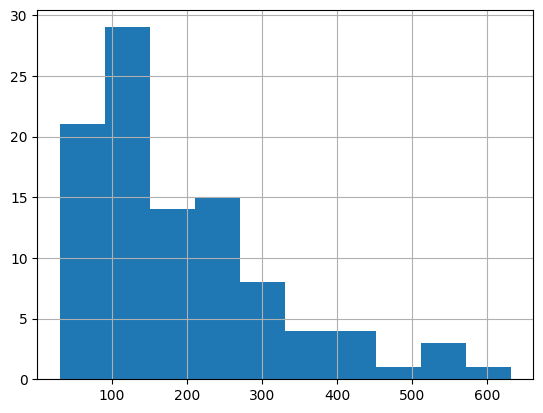

In [11]:
df['duration_sec'].hist()

Mel Spectrogram

In [13]:
audio

NameError: name 'audio' is not defined

In [12]:
sr = 22050
n_fft = 2048
hop_length = 512
n_mels = 128

In [ ]:
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

mel = librosa.power_to_db(mel)

Picked file: Lucky Star- Patty's (Kirby's sand canyon).mp3
Loaded audio shape: (1605888,)
Sample rate: 22050
Duration (sec): 72.83
Mel spectrogram shape: (128, 3137)
Log-mel spectrogram shape: (128, 3137)
Mel min/max: 0.0000 / 2129.5137
Mel dB min/max: -80.0000 / 0.0000


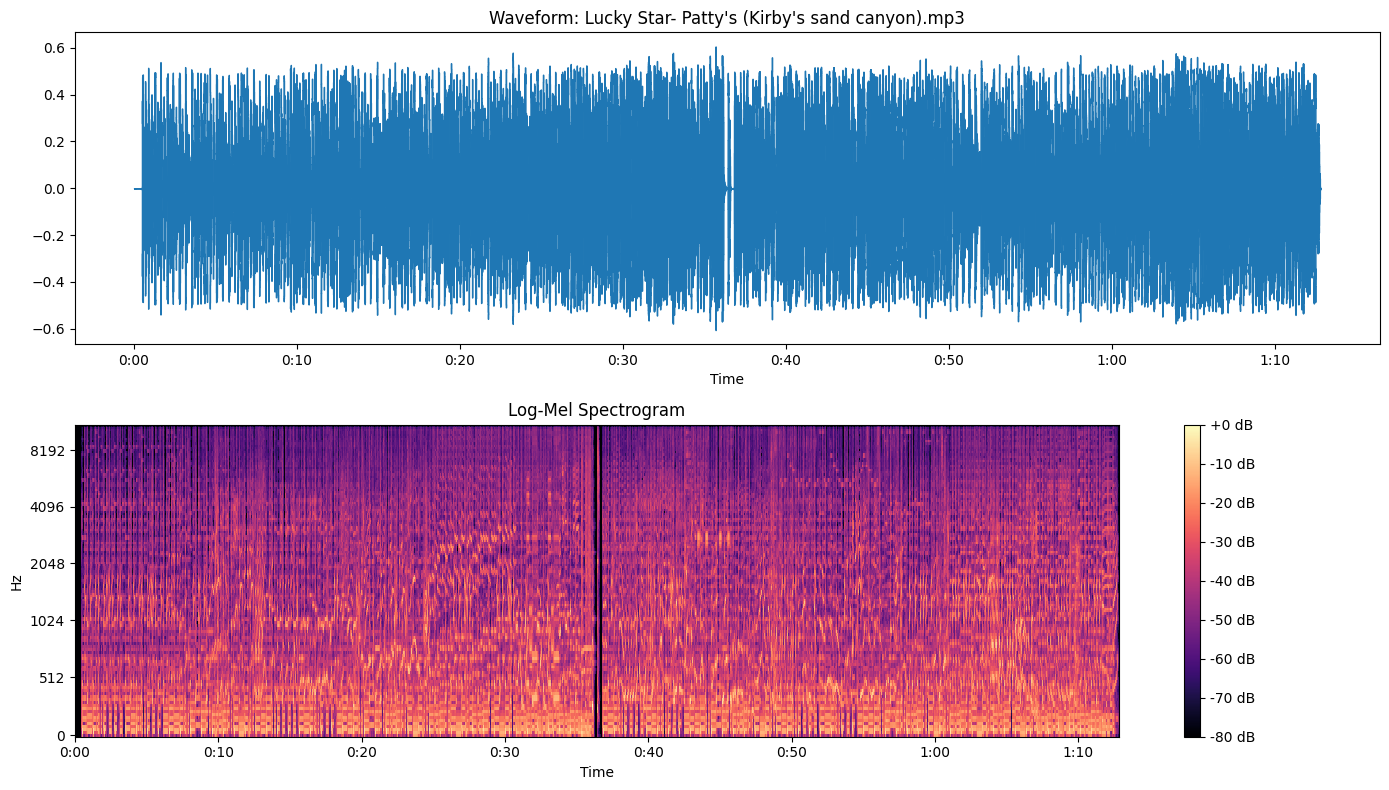

In [2]:
import os
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ===== 路径改成你的 =====
audio_dir = r"D:\Study Abroad\course\DSCI498\Project\data\unpacked\6909"

# ===== 参数 =====
target_sr = 22050
n_fft = 2048
hop_length = 512
n_mels = 128

# ===== 随机选一个音频 =====
audio_files = [
    f for f in os.listdir(audio_dir)
    if f.lower().endswith((".mp3", ".wav", ".ogg"))
]

if not audio_files:
    raise ValueError("No audio files found in the audio directory.")

picked = random.choice(audio_files)
audio_path = os.path.join(audio_dir, picked)

print(f"Picked file: {picked}")

# ===== 读取音频 =====
# sr=22050: 统一采样率
# mono=True: 转成单声道
y, sr = librosa.load(audio_path, sr=target_sr, mono=True)

duration_sec = len(y) / sr
print(f"Loaded audio shape: {y.shape}")
print(f"Sample rate: {sr}")
print(f"Duration (sec): {duration_sec:.2f}")

# ===== Mel Spectrogram =====
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    power=2.0
)

# 转成 dB，更适合看，也常用于模型输入
mel_db = librosa.power_to_db(mel, ref=np.max)

print(f"Mel spectrogram shape: {mel.shape}")
print(f"Log-mel spectrogram shape: {mel_db.shape}")
print(f"Mel min/max: {mel.min():.4f} / {mel.max():.4f}")
print(f"Mel dB min/max: {mel_db.min():.4f} / {mel_db.max():.4f}")

# ===== 画图检查 =====
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 波形图
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title(f"Waveform: {picked}")

# Mel spectrogram 图
img = librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel",
    ax=axes[1]
)
axes[1].set_title("Log-Mel Spectrogram")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

In [8]:
mel_db

array([[-80.      , -80.      , -80.      , ..., -60.272804, -67.08013 ,
        -79.486694],
       [-80.      , -80.      , -80.      , ..., -46.934242, -55.953667,
        -77.151596],
       [-80.      , -80.      , -80.      , ..., -48.861507, -54.885216,
        -80.      ],
       ...,
       [-80.      , -80.      , -80.      , ..., -70.11931 , -75.990974,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -70.736404, -76.65585 ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ]], dtype=float32)

In [15]:
from pathlib import Path
import json
from collections import Counter, defaultdict
import pandas as pd

# 改成你自己的路径
unpacked_root = Path(r"D:\Study Abroad\course\DSCI498\Project\data\unpacked")

type_counter = Counter()
type_files = defaultdict(set)
bad_files = []

# 找所有 notes.json
notes_files = list(unpacked_root.rglob("*.notes.json"))

print(f"Found {len(notes_files)} notes.json files.")

for notes_path in notes_files:
    try:
        with open(notes_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        # 兼容两种常见结构：
        # 1) data 是 list[event]
        # 2) data 是 dict，events 在 data["notes"] 里
        if isinstance(data, list):
            events = data
        elif isinstance(data, dict):
            if "notes" in data:
                events = data["notes"]
            elif "events" in data:
                events = data["events"]
            else:
                events = []
        else:
            events = []

        for event in events:
            if not isinstance(event, dict):
                continue

            event_type = event.get("type", None)
            if event_type is None:
                continue

            type_counter[event_type] += 1
            type_files[event_type].add(str(notes_path))

    except Exception as e:
        bad_files.append((str(notes_path), str(e)))

# 输出所有 event type
print("\n=== All event types ===")
for t in sorted(type_counter.keys()):
    print(t)

# 输出计数
print("\n=== Event type counts ===")
for t, c in type_counter.most_common():
    print(f"{t}: {c}")

# 保存成表
rows = []
for t in sorted(type_counter.keys()):
    rows.append({
        "event_type": t,
        "count": type_counter[t],
        "n_files": len(type_files[t]),
    })

df = pd.DataFrame(rows).sort_values("count", ascending=False)

out_csv = unpacked_root / "event_type_summary.csv"
df.to_csv(out_csv, index=False, encoding="utf-8-sig")

print(f"\nSaved summary to: {out_csv}")

# 如果想看每种 type 出现在哪些文件里，额外保存一个详细表
detail_rows = []
for t in sorted(type_files.keys()):
    for fp in sorted(type_files[t]):
        detail_rows.append({
            "event_type": t,
            "notes_json": fp
        })

detail_df = pd.DataFrame(detail_rows)

print(f"Saved detail file to: {detail_csv}")

Found 330 notes.json files.

=== All event types ===
bigdon
bigkat
bpmchange
don
drumroll
kat
sliderend
sliderstart

=== Event type counts ===
don: 110659
kat: 108230
bigdon: 5523
bigkat: 4942
bpmchange: 1158
sliderend: 655
drumroll: 450
sliderstart: 205

Saved summary to: D:\Study Abroad\course\DSCI498\Project\data\unpacked\event_type_summary.csv


NameError: name 'detail_csv' is not defined

In [18]:
detail_df['event_type'].nunique()

8

Found 330 notes.json files.

=== Event type counts ===
don: 110659
kat: 108230
bigdon: 5523
bigkat: 4942
bpmchange: 1158
sliderend: 655
drumroll: 450
sliderstart: 205

=== File-level summary ===
          n_events  duration_sec  events_per_sec  n_long_events
count   330.000000    330.000000      330.000000     330.000000
mean    702.490909    153.209803        4.264579       3.969697
std     666.036173     88.417802        2.050019       5.186989
min      40.000000     30.603000        0.809235       0.000000
25%     274.500000     92.841048        2.677639       0.000000
50%     498.000000    122.526316        4.108363       2.000000
75%     896.500000    205.262895        5.676333       6.000000
max    4127.000000    552.856571       10.179906      38.000000

=== Inter-event delta summary (ms) ===
count    231492.000000
mean        218.405971
std         392.054783
min           0.000000
10%          73.170732
25%          86.206897
50%         157.894737
75%         250.000000
90%  

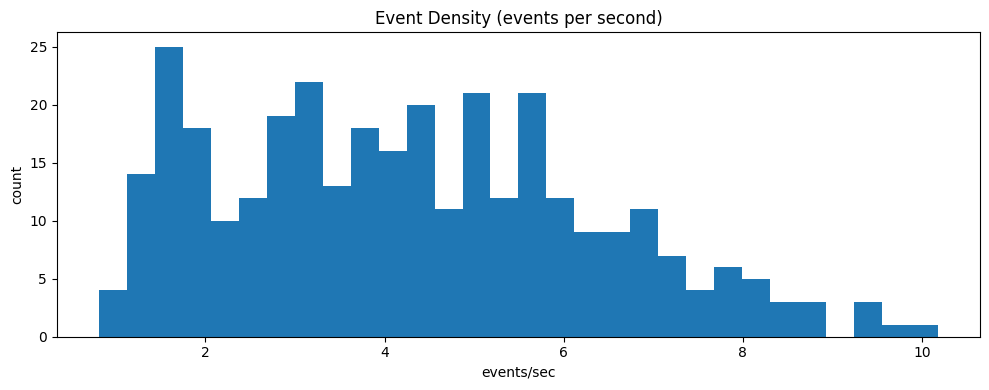

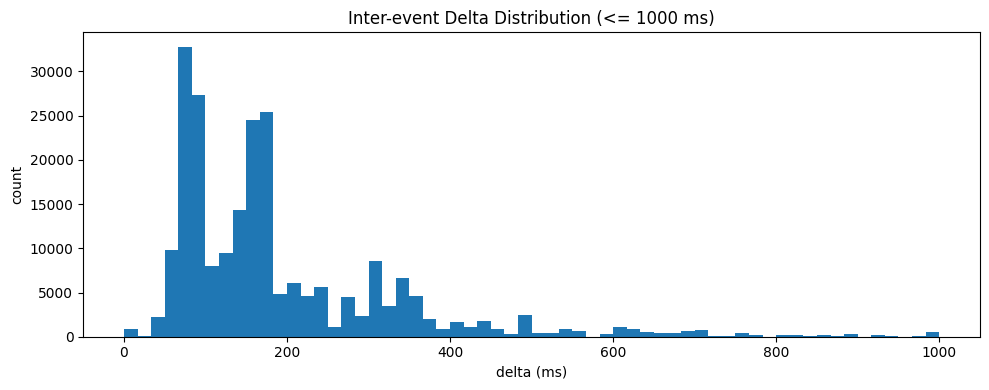


Saved analysis outputs to: D:\Study Abroad\course\DSCI498\Project\data\unpacked\analysis_outputs

No bad files.


In [19]:
from pathlib import Path
import json
import math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 改成你的路径
unpacked_root = Path(r"D:\Study Abroad\course\DSCI498\Project\data\unpacked")

notes_files = list(unpacked_root.rglob("*.notes.json"))
print(f"Found {len(notes_files)} notes.json files.")

# -----------------------------
# 1) 扫描所有 notes.json
# -----------------------------
event_counter = Counter()
all_deltas = []
file_rows = []
bad_files = []

# 候选切片长度（秒）
candidate_seg_secs = [3, 5, 8, 10]

# 每个切片长度对应的统计
seg_stats = {s: [] for s in candidate_seg_secs}

# 长事件类型
long_event_types = {"sliderstart", "sliderend", "drumroll"}

for fp in notes_files:
    try:
        with open(fp, "r", encoding="utf-8") as f:
            data = json.load(f)

        if isinstance(data, list):
            events = data
        elif isinstance(data, dict):
            if "notes" in data:
                events = data["notes"]
            elif "events" in data:
                events = data["events"]
            else:
                events = []
        else:
            events = []

        # 只保留有 time/type 的 event
        clean_events = []
        for e in events:
            if not isinstance(e, dict):
                continue
            if "time" not in e or "type" not in e:
                continue
            clean_events.append(e)

        if len(clean_events) == 0:
            continue

        # 按时间排序
        clean_events = sorted(clean_events, key=lambda x: float(x["time"]))

        times = np.array([float(e["time"]) for e in clean_events], dtype=float)
        types = [str(e["type"]) for e in clean_events]

        # 事件类型计数
        event_counter.update(types)

        # 相邻时间差
        if len(times) > 1:
            deltas = np.diff(times)
            # 过滤极端异常负值（理论上排序后不该有）
            deltas = deltas[deltas >= 0]
            all_deltas.extend(deltas.tolist())
        else:
            deltas = np.array([])

        # 每个文件的基本统计
        duration_ms = times[-1] - times[0]
        duration_sec = duration_ms / 1000.0 if duration_ms > 0 else 0.0
        n_events = len(times)
        events_per_sec = (n_events / duration_sec) if duration_sec > 0 else np.nan
        n_long_events = sum(t in long_event_types for t in types)

        file_rows.append({
            "notes_json": str(fp),
            "n_events": n_events,
            "duration_sec": duration_sec,
            "events_per_sec": events_per_sec,
            "n_long_events": n_long_events,
            "has_long_events": n_long_events > 0,
        })

        # -----------------------------
        # 2) 对不同切片长度做粗分析
        # -----------------------------
        for seg_sec in candidate_seg_secs:
            seg_ms = seg_sec * 1000.0

            start_t = times[0]
            end_t = times[-1]

            n_segments = int(math.ceil((end_t - start_t) / seg_ms)) if end_t > start_t else 1

            seg_event_counts = []
            seg_long_counts = []
            unmatched_slider_segments = 0

            for i in range(n_segments):
                seg_start = start_t + i * seg_ms
                seg_end = seg_start + seg_ms

                mask = (times >= seg_start) & (times < seg_end)
                seg_types = [types[j] for j in range(len(types)) if mask[j]]

                seg_event_counts.append(len(seg_types))
                seg_long_counts.append(sum(t in long_event_types for t in seg_types))

                # 粗略判断：segment 内只有 start 没有 end，或只有 end 没有 start
                has_start = "sliderstart" in seg_types
                has_end = "sliderend" in seg_types
                if has_start != has_end:
                    unmatched_slider_segments += 1

            seg_stats[seg_sec].append({
                "notes_json": str(fp),
                "n_segments": n_segments,
                "avg_events_per_segment": float(np.mean(seg_event_counts)) if seg_event_counts else 0.0,
                "median_events_per_segment": float(np.median(seg_event_counts)) if seg_event_counts else 0.0,
                "max_events_per_segment": int(np.max(seg_event_counts)) if seg_event_counts else 0,
                "segments_with_long_events": int(sum(c > 0 for c in seg_long_counts)),
                "unmatched_slider_segments": unmatched_slider_segments,
            })

    except Exception as e:
        bad_files.append((str(fp), str(e)))

# -----------------------------
# 3) 输出整体统计
# -----------------------------
file_df = pd.DataFrame(file_rows)

print("\n=== Event type counts ===")
for k, v in event_counter.most_common():
    print(f"{k}: {v}")

print("\n=== File-level summary ===")
print(file_df[["n_events", "duration_sec", "events_per_sec", "n_long_events"]].describe())

# 相邻时间差统计
delta_arr = np.array(all_deltas, dtype=float)

print("\n=== Inter-event delta summary (ms) ===")
print(pd.Series(delta_arr).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# 常见范围占比
bins_to_check = [20, 40, 80, 120, 160, 200, 500, 1000]
print("\n=== Percent of deltas <= threshold ===")
for b in bins_to_check:
    pct = (delta_arr <= b).mean() * 100 if len(delta_arr) else 0
    print(f"<= {b:4d} ms : {pct:6.2f}%")

# -----------------------------
# 4) 候选切片长度统计
# -----------------------------
print("\n=== Segment-length comparison ===")
seg_summary_rows = []

for seg_sec, rows in seg_stats.items():
    sdf = pd.DataFrame(rows)
    summary = {
        "segment_sec": seg_sec,
        "avg_n_segments_per_file": sdf["n_segments"].mean(),
        "avg_events_per_segment": sdf["avg_events_per_segment"].mean(),
        "median_events_per_segment": sdf["median_events_per_segment"].median(),
        "avg_max_events_per_segment": sdf["max_events_per_segment"].mean(),
        "avg_segments_with_long_events": sdf["segments_with_long_events"].mean(),
        "avg_unmatched_slider_segments": sdf["unmatched_slider_segments"].mean(),
    }
    seg_summary_rows.append(summary)

seg_summary_df = pd.DataFrame(seg_summary_rows).sort_values("segment_sec")
print(seg_summary_df.to_string(index=False))

# -----------------------------
# 5) 画图
# -----------------------------
plt.figure(figsize=(10, 4))
plt.hist(file_df["events_per_sec"].dropna(), bins=30)
plt.title("Event Density (events per second)")
plt.xlabel("events/sec")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
# 为了看清主体，先只画 <=1000ms 的 delta
delta_clip = delta_arr[delta_arr <= 1000]
plt.hist(delta_clip, bins=60)
plt.title("Inter-event Delta Distribution (<= 1000 ms)")
plt.xlabel("delta (ms)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# -----------------------------
# 6) 保存结果
# -----------------------------
out_dir = unpacked_root / "analysis_outputs"
out_dir.mkdir(exist_ok=True)

file_df.to_csv(out_dir / "notes_file_summary.csv", index=False, encoding="utf-8-sig")
seg_summary_df.to_csv(out_dir / "segment_length_summary.csv", index=False, encoding="utf-8-sig")

pd.DataFrame({"delta_ms": delta_arr}).to_csv(
    out_dir / "all_inter_event_deltas.csv",
    index=False,
    encoding="utf-8-sig"
)

print(f"\nSaved analysis outputs to: {out_dir}")

if bad_files:
    print("\n=== Bad files ===")
    for x in bad_files[:20]:
        print(x)
else:
    print("\nNo bad files.")

In [20]:
seg_summary_rows

[{'segment_sec': 3,
  'avg_n_segments_per_file': 51.587878787878786,
  'avg_events_per_segment': 12.6341872257358,
  'median_events_per_segment': 13.0,
  'avg_max_events_per_segment': 19.490909090909092,
  'avg_segments_with_long_events': 2.6575757575757577,
  'avg_unmatched_slider_segments': 1.493939393939394},
 {'segment_sec': 5,
  'avg_n_segments_per_file': 31.154545454545456,
  'avg_events_per_segment': 20.876294340443582,
  'median_events_per_segment': 21.75,
  'avg_max_events_per_segment': 30.63030303030303,
  'avg_segments_with_long_events': 2.378787878787879,
  'avg_unmatched_slider_segments': 1.415151515151515},
 {'segment_sec': 8,
  'avg_n_segments_per_file': 19.663636363636364,
  'avg_events_per_segment': 32.99081892767681,
  'median_events_per_segment': 33.5,
  'avg_max_events_per_segment': 46.872727272727275,
  'avg_segments_with_long_events': 2.021212121212121,
  'avg_unmatched_slider_segments': 1.2636363636363637},
 {'segment_sec': 10,
  'avg_n_segments_per_file': 15.8,


Found 330 timing.json files.

=== Per-file weighted BPM summary ===
       weighted_avg_bpm  four_beats_sec_at_weighted_bpm  n_timing_points  \
count        330.000000                      330.000000       330.000000   
mean         164.830389                        1.538016         3.509091   
std           35.728922                        0.399405         5.848251   
min           62.736595                        1.000000         1.000000   
10%          119.200000                        1.170732         1.000000   
25%          137.750000                        1.297297         1.000000   
50%          170.500000                        1.407637         1.000000   
75%          185.000000                        1.742440         4.000000   
90%          205.000000                        2.014286         8.000000   
95%          224.000000                        2.426939        12.000000   
max          240.000000                        3.825518        49.000000   

       unique_bpms 

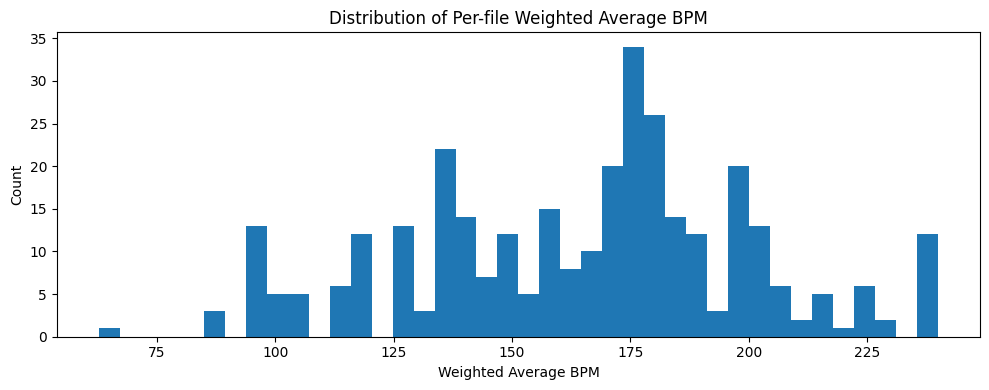

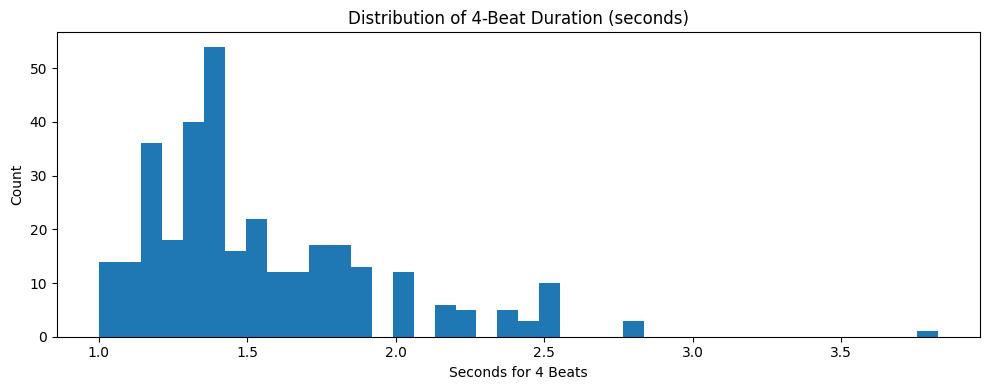

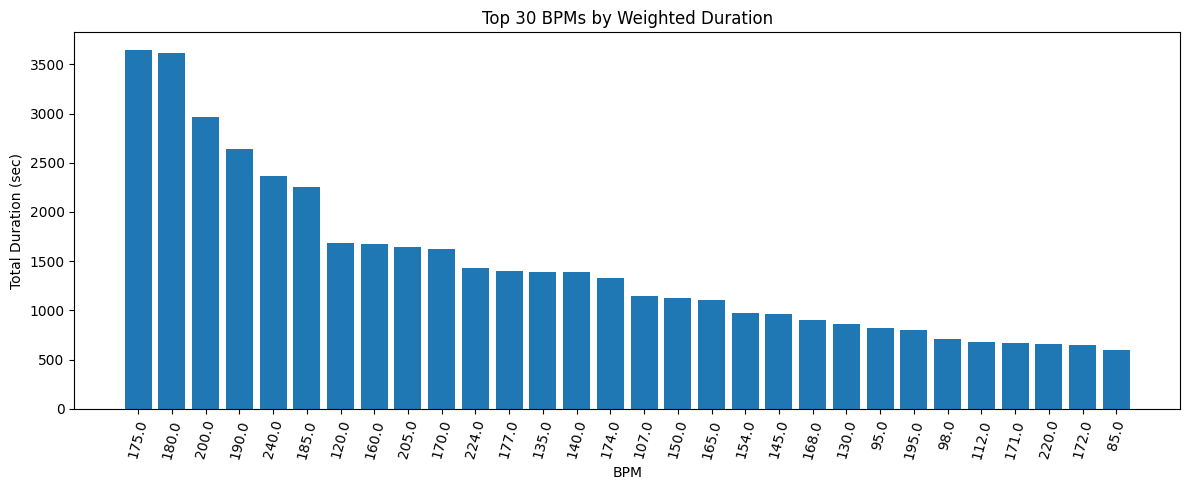


Saved timing analysis outputs to: D:\Study Abroad\course\DSCI498\Project\data\unpacked\timing_analysis_outputs

No bad files.


In [21]:
from pathlib import Path
import json
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= 改成你的路径 =========
unpacked_root = Path(r"D:\Study Abroad\course\DSCI498\Project\data\unpacked")

timing_files = list(unpacked_root.rglob("*.timing.json"))
print(f"Found {len(timing_files)} timing.json files.")

# -----------------------------
# 工具函数
# -----------------------------
def try_get_end_time_ms(timing_path: Path):
    """
    用同名 notes.json 的最后一个事件时间作为谱面结束时间。
    如果拿不到，就返回 None。
    """
    notes_path = timing_path.with_name(timing_path.name.replace(".timing.json", ".notes.json"))
    if not notes_path.exists():
        return None

    try:
        with open(notes_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        if isinstance(data, list):
            events = data
        elif isinstance(data, dict):
            if "notes" in data:
                events = data["notes"]
            elif "events" in data:
                events = data["events"]
            else:
                events = []
        else:
            events = []

        times = []
        for e in events:
            if isinstance(e, dict) and "time" in e:
                try:
                    times.append(float(e["time"]))
                except:
                    pass

        if len(times) == 0:
            return None

        return max(times)

    except Exception:
        return None


def extract_timing_events(obj):
    """
    尽量兼容不同 timing.json 结构：
    - list[dict]
    - dict["timing_points"]
    - dict["timing"]
    - dict["events"]
    """
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for k in ["timing_points", "timing", "events", "points"]:
            if k in obj and isinstance(obj[k], list):
                return obj[k]
    return []


def normalize_bpm_event(e):
    """
    把一个 timing event 尽量转成:
    {
        "time": float(ms),
        "bpm": float
    }
    支持几种常见写法：
    - {"time": ..., "bpm": ...}
    - {"time": ..., "ms_per_beat": ...}
    - {"time": ..., "beatLength": ...}
    - {"time": ..., "mpb": ...}
    """
    if not isinstance(e, dict):
        return None

    # time
    time_val = None
    for tk in ["time", "offset", "start_time", "start"]:
        if tk in e:
            try:
                time_val = float(e[tk])
                break
            except:
                pass

    if time_val is None:
        return None

    # bpm
    bpm_val = None

    if "bpm" in e:
        try:
            bpm_val = float(e["bpm"])
        except:
            bpm_val = None

    # 常见 beat length / ms per beat
    if bpm_val is None:
        for bk in ["ms_per_beat", "beatLength", "beat_length", "mpb"]:
            if bk in e:
                try:
                    ms_per_beat = float(e[bk])
                    if ms_per_beat > 0:
                        bpm_val = 60000.0 / ms_per_beat
                    break
                except:
                    pass

    # 有些 osu 继承 timing point 可能是负值，先过滤掉
    if bpm_val is None or bpm_val <= 0:
        return None

    return {"time": time_val, "bpm": bpm_val}


# -----------------------------
# 主扫描
# -----------------------------
per_file_rows = []
segment_rows = []
bad_files = []

for timing_path in timing_files:
    try:
        with open(timing_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        raw_events = extract_timing_events(data)
        norm_events = []

        for e in raw_events:
            ne = normalize_bpm_event(e)
            if ne is not None:
                norm_events.append(ne)

        if len(norm_events) == 0:
            continue

        # 按时间排序
        norm_events = sorted(norm_events, key=lambda x: x["time"])

        # 去掉重复时间且后者覆盖前者（保留最后一个）
        dedup = {}
        for e in norm_events:
            dedup[e["time"]] = e["bpm"]
        norm_events = [{"time": t, "bpm": dedup[t]} for t in sorted(dedup.keys())]

        end_time_ms = try_get_end_time_ms(timing_path)
        if end_time_ms is None:
            # 如果拿不到 end time，就粗略用最后一个 timing point 后再延长 60 秒
            end_time_ms = norm_events[-1]["time"] + 60000.0

        # 按相邻 timing point 区间做 duration-weighted BPM
        weighted_sum = 0.0
        total_dur = 0.0
        bpm_list = []

        for i, e in enumerate(norm_events):
            start_t = e["time"]
            bpm = e["bpm"]

            if i < len(norm_events) - 1:
                end_t = norm_events[i + 1]["time"]
            else:
                end_t = end_time_ms

            dur_ms = max(0.0, end_t - start_t)
            dur_sec = dur_ms / 1000.0

            if dur_sec <= 0:
                continue

            weighted_sum += bpm * dur_sec
            total_dur += dur_sec
            bpm_list.append(bpm)

            segment_rows.append({
                "timing_json": str(timing_path),
                "start_ms": start_t,
                "end_ms": end_t,
                "duration_sec": dur_sec,
                "bpm": bpm,
                "four_beats_sec": 4 * 60.0 / bpm,
            })

        if total_dur == 0:
            continue

        weighted_bpm = weighted_sum / total_dur

        per_file_rows.append({
            "timing_json": str(timing_path),
            "n_timing_points": len(norm_events),
            "unique_bpms": len(set(round(x, 6) for x in bpm_list)),
            "min_bpm": min(bpm_list),
            "max_bpm": max(bpm_list),
            "weighted_avg_bpm": weighted_bpm,
            "map_duration_sec_for_weighting": total_dur,
            "four_beats_sec_at_weighted_bpm": 4 * 60.0 / weighted_bpm,
        })

    except Exception as e:
        bad_files.append((str(timing_path), str(e)))

# -----------------------------
# 汇总
# -----------------------------
per_file_df = pd.DataFrame(per_file_rows)
segment_df = pd.DataFrame(segment_rows)

print("\n=== Per-file weighted BPM summary ===")
print(
    per_file_df[
        ["weighted_avg_bpm", "four_beats_sec_at_weighted_bpm", "n_timing_points", "unique_bpms"]
    ].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])
)

# 全局 duration-weighted BPM
global_weighted_bpm = np.average(segment_df["bpm"], weights=segment_df["duration_sec"])
global_four_beats_sec = 4 * 60.0 / global_weighted_bpm

print("\n=== Global duration-weighted BPM ===")
print(f"Global weighted BPM: {global_weighted_bpm:.3f}")
print(f"Estimated duration of 4 beats at global weighted BPM: {global_four_beats_sec:.3f} sec")

# 最常见 BPM（按时间加权）
# 为了防止浮点数太碎，做一个四舍五入
segment_df["bpm_round"] = segment_df["bpm"].round(2)

bpm_weighted = (
    segment_df.groupby("bpm_round")["duration_sec"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("\n=== Top 20 BPMs by weighted duration ===")
print(bpm_weighted.head(20).to_string(index=False))

# -----------------------------
# 画图
# -----------------------------
plt.figure(figsize=(10, 4))
plt.hist(per_file_df["weighted_avg_bpm"], bins=40)
plt.title("Distribution of Per-file Weighted Average BPM")
plt.xlabel("Weighted Average BPM")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(per_file_df["four_beats_sec_at_weighted_bpm"], bins=40)
plt.title("Distribution of 4-Beat Duration (seconds)")
plt.xlabel("Seconds for 4 Beats")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 全局 BPM 加权分布（只看前若干常见值）
top_n = 30
top_df = bpm_weighted.head(top_n)

plt.figure(figsize=(12, 5))
plt.bar(top_df["bpm_round"].astype(str), top_df["duration_sec"])
plt.xticks(rotation=75)
plt.title(f"Top {top_n} BPMs by Weighted Duration")
plt.xlabel("BPM")
plt.ylabel("Total Duration (sec)")
plt.tight_layout()
plt.show()

# -----------------------------
# 保存
# -----------------------------
out_dir = unpacked_root / "timing_analysis_outputs"
out_dir.mkdir(exist_ok=True)

per_file_df.to_csv(out_dir / "timing_per_file_summary.csv", index=False, encoding="utf-8-sig")
segment_df.to_csv(out_dir / "timing_weighted_segments.csv", index=False, encoding="utf-8-sig")
bpm_weighted.to_csv(out_dir / "timing_bpm_weighted_distribution.csv", index=False, encoding="utf-8-sig")

print(f"\nSaved timing analysis outputs to: {out_dir}")

if bad_files:
    print("\n=== Bad files ===")
    for fp, err in bad_files[:20]:
        print(fp, "->", err)
else:
    print("\nNo bad files.")

In [26]:
import json
from pathlib import Path
from collections import Counter

ROOT = Path(r"D:\Study Abroad\course\DSCI498\Project\data\unpacked")
PATTERN = "*\parsed\*.timing.json"

# 是否把“同一BPM的重复声明”算作变速
COUNT_DUPLICATE_DECLARATION_AS_CHANGE = False

# 浮点比较容忍度
EPS = 1e-6


def bpm_from_ms_per_beat(ms_per_beat: float) -> float:
    return 60000.0 / ms_per_beat


def almost_equal(a: float, b: float, eps: float = EPS) -> bool:
    return abs(a - b) <= eps


def scan_one_timing_file(path: Path):
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    timing_points = data.get("timing_points", [])
    uninherited_points = []

    for tp in timing_points:
        if int(tp.get("uninherited", 0)) == 1:
            ms_per_beat = float(tp["ms_per_beat"])
            bpm = bpm_from_ms_per_beat(ms_per_beat)
            uninherited_points.append(
                {
                    "offset": float(tp["offset"]),
                    "ms_per_beat": ms_per_beat,
                    "bpm": bpm,
                    "meter": int(tp.get("meter", 4)),
                }
            )

    if not uninherited_points:
        return {
            "path": path,
            "has_bpm_points": False,
            "has_real_bpm_change": False,
            "num_uninherited_points": 0,
            "unique_bpms": [],
            "bpm_sequence": [],
            "real_change_count": 0,
        }

    # 按时间排序
    uninherited_points.sort(key=lambda x: x["offset"])

    bpm_sequence = [x["bpm"] for x in uninherited_points]

    # 去掉“连续重复声明”的 BPM 序列
    dedup_bpms = [bpm_sequence[0]]
    for bpm in bpm_sequence[1:]:
        if not almost_equal(bpm, dedup_bpms[-1]):
            dedup_bpms.append(bpm)

    if COUNT_DUPLICATE_DECLARATION_AS_CHANGE:
        has_real_bpm_change = len(bpm_sequence) > 1
        real_change_count = max(0, len(bpm_sequence) - 1)
    else:
        has_real_bpm_change = len(dedup_bpms) > 1
        real_change_count = max(0, len(dedup_bpms) - 1)

    unique_bpms = []
    for bpm in bpm_sequence:
        if not any(almost_equal(bpm, x) for x in unique_bpms):
            unique_bpms.append(bpm)

    return {
        "path": path,
        "has_bpm_points": True,
        "has_real_bpm_change": has_real_bpm_change,
        "num_uninherited_points": len(uninherited_points),
        "unique_bpms": unique_bpms,
        "bpm_sequence": bpm_sequence,
        "real_change_count": real_change_count,
        "timing_points_used": uninherited_points,
    }


def main():
    files = sorted(ROOT.glob(PATTERN))
    if not files:
        print("No timing.json files found.")
        print(f"Checked: {ROOT}")
        print(f"Pattern: {PATTERN}")
        return

    results = []
    no_bpm_files = []
    changed_files = []
    unchanged_files = []

    bpm_counter = Counter()

    for path in files:
        result = scan_one_timing_file(path)
        results.append(result)

        if not result["has_bpm_points"]:
            no_bpm_files.append(result)
            continue

        # 统计所有主 BPM
        for bpm in result["unique_bpms"]:
            bpm_counter[round(bpm, 6)] += 1

        if result["has_real_bpm_change"]:
            changed_files.append(result)
        else:
            unchanged_files.append(result)

    print("=" * 80)
    print(f"Total timing files scanned: {len(files)}")
    print(f"No uninherited BPM points : {len(no_bpm_files)}")
    print(f"No real BPM change        : {len(unchanged_files)}")
    print(f"Has real BPM change       : {len(changed_files)}")
    print("=" * 80)

    print("\nTop BPMs in dataset:")
    for bpm, cnt in bpm_counter.most_common(20):
        print(f"  BPM {bpm:>10} : {cnt} files")

    print("\nFiles WITH real BPM change:")
    for r in changed_files[:50]:
        print("-" * 80)
        print(r["path"])
        print(f"  uninherited points : {r['num_uninherited_points']}")
        print(f"  unique BPMs        : {[round(x, 6) for x in r['unique_bpms']]}")
        print(f"  real change count  : {r['real_change_count']}")

    # 保存详细结果，方便后续筛选
    out_rows = []
    for r in results:
        out_rows.append(
            {
                "path": str(r["path"]),
                "has_bpm_points": r["has_bpm_points"],
                "has_real_bpm_change": r["has_real_bpm_change"],
                "num_uninherited_points": r["num_uninherited_points"],
                "unique_bpms": [round(x, 6) for x in r["unique_bpms"]],
                "bpm_sequence": [round(x, 6) for x in r["bpm_sequence"]],
                "real_change_count": r["real_change_count"],
            }
        )

    out_path = ROOT / "bpm_change_scan_results.json"
    with out_path.open("w", encoding="utf-8") as f:
        json.dump(out_rows, f, ensure_ascii=False, indent=2)

    print("\nSaved detailed results to:")
    print(out_path)


if __name__ == "__main__":
    main()

Total timing files scanned: 330
No uninherited BPM points : 0
No real BPM change        : 290
Has real BPM change       : 40

Top BPMs in dataset:
  BPM      180.0 : 20 files
  BPM      175.0 : 20 files
  BPM      200.0 : 20 files
  BPM      120.0 : 18 files
  BPM      160.0 : 18 files
  BPM      185.0 : 17 files
  BPM      130.0 : 16 files
  BPM      135.0 : 16 files
  BPM      240.0 : 16 files
  BPM      190.0 : 15 files
  BPM      150.0 : 13 files
  BPM      140.0 : 12 files
  BPM      170.0 : 12 files
  BPM       98.0 : 10 files
  BPM       90.0 : 10 files
  BPM      205.0 : 9 files
  BPM      112.0 : 9 files
  BPM      177.0 : 8 files
  BPM      145.0 : 8 files
  BPM      168.0 : 8 files

Files WITH real BPM change:
--------------------------------------------------------------------------------
D:\Study Abroad\course\DSCI498\Project\data\unpacked\1096486\parsed\Corpo-Mente & Igorrr - Arsalein  Pavor Nocturnus [2015]  Equus (3san) [Nightmare].timing.json
  uninherited points : 15


In [27]:
import json
from pathlib import Path
from collections import defaultdict

ROOT = Path(r"D:\Study Abroad\course\DSCI498\Project\data\unpacked")
SCAN_RESULT = ROOT / "bpm_change_scan_results.json"

DELETE_CHANGED_FILES = True   # True=真的删除；False=只打印不删除
AUDIO_EXTS = {".mp3", ".ogg"}

def load_scan_results(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def sibling_file(path: Path, old_suffix: str, new_suffix: str) -> Path:
    name = path.name
    if not name.endswith(old_suffix):
        raise ValueError(f"Unexpected filename: {path}")
    return path.with_name(name[:-len(old_suffix)] + new_suffix)

def delete_changed_chart_files(results):
    deleted = []
    missing = []

    for row in results:
        if not row.get("has_real_bpm_change", False):
            continue

        timing_path = Path(row["path"])
        notes_path = sibling_file(timing_path, ".timing.json", ".notes.json")
        meta_path = sibling_file(timing_path, ".timing.json", ".metadata.json")

        for p in [timing_path, notes_path, meta_path]:
            if p.exists():
                if DELETE_CHANGED_FILES:
                    p.unlink()
                deleted.append(str(p))
            else:
                missing.append(str(p))

    return deleted, missing

def summarize_remaining_parsed(root: Path):
    rows = []

    for parsed_dir in sorted(root.glob(r"*\parsed")):
        notes = list(parsed_dir.glob("*.notes.json"))
        timing = list(parsed_dir.glob("*.timing.json"))
        metadata = list(parsed_dir.glob("*.metadata.json"))

        rows.append({
            "parsed_dir": str(parsed_dir),
            "notes_count": len(notes),
            "timing_count": len(timing),
            "metadata_count": len(metadata),
        })

    return rows

def check_audio_files(root: Path):
    rows = []

    for song_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
        audio_files = []
        for p in song_dir.iterdir():
            if p.is_file() and p.suffix.lower() in AUDIO_EXTS:
                audio_files.append(p.name)

        rows.append({
            "song_dir": str(song_dir),
            "audio_count": len(audio_files),
            "audio_files": audio_files,
            "ok_exactly_one_audio": (len(audio_files) == 1),
        })

    return rows

def main():
    results = load_scan_results(SCAN_RESULT)

    changed_count = sum(1 for r in results if r.get("has_real_bpm_change", False))
    unchanged_count = sum(1 for r in results if not r.get("has_real_bpm_change", False))

    print("=" * 80)
    print(f"Charts with real BPM change    : {changed_count}")
    print(f"Charts without real BPM change : {unchanged_count}")
    print("=" * 80)

    deleted, missing = delete_changed_chart_files(results)

    print(f"\nDeleted files : {len(deleted)}")
    print(f"Missing files : {len(missing)}")

    if missing:
        print("\nFirst 20 missing files:")
        for x in missing[:20]:
            print("  ", x)

    parsed_summary = summarize_remaining_parsed(ROOT)

    print("\nParsed folder summary (first 20):")
    for row in parsed_summary[:20]:
        print(
            f"{row['parsed_dir']}\n"
            f"  notes={row['notes_count']} timing={row['timing_count']} metadata={row['metadata_count']}"
        )

    bad_parsed = [
        r for r in parsed_summary
        if not (r["notes_count"] == r["timing_count"] == r["metadata_count"])
    ]

    print("\nParsed folders with mismatched counts:")
    print(f"  {len(bad_parsed)}")
    for row in bad_parsed[:50]:
        print(
            f"{row['parsed_dir']} -> "
            f"notes={row['notes_count']}, timing={row['timing_count']}, metadata={row['metadata_count']}"
        )

    audio_summary = check_audio_files(ROOT)

    bad_audio = [r for r in audio_summary if not r["ok_exactly_one_audio"]]

    print("\nFolders without exactly one MP3/OGG:")
    print(f"  {len(bad_audio)}")
    for row in bad_audio[:50]:
        print(f"{row['song_dir']} -> count={row['audio_count']} files={row['audio_files']}")

    # 保存结果
    out_delete = ROOT / "post_delete_summary_parsed.json"
    out_audio = ROOT / "post_delete_audio_check.json"

    with out_delete.open("w", encoding="utf-8") as f:
        json.dump(parsed_summary, f, ensure_ascii=False, indent=2)

    with out_audio.open("w", encoding="utf-8") as f:
        json.dump(audio_summary, f, ensure_ascii=False, indent=2)

    print("\nSaved:")
    print(f"  {out_delete}")
    print(f"  {out_audio}")

if __name__ == "__main__":
    main()

Charts with real BPM change    : 40
Charts without real BPM change : 290

Deleted files : 120
Missing files : 0

Parsed folder summary (first 20):
D:\Study Abroad\course\DSCI498\Project\data\unpacked\1024653\parsed
  notes=3 timing=3 metadata=3
D:\Study Abroad\course\DSCI498\Project\data\unpacked\1057540\parsed
  notes=2 timing=2 metadata=2
D:\Study Abroad\course\DSCI498\Project\data\unpacked\1086408\parsed
  notes=2 timing=2 metadata=2
D:\Study Abroad\course\DSCI498\Project\data\unpacked\1096486\parsed
  notes=0 timing=0 metadata=0
D:\Study Abroad\course\DSCI498\Project\data\unpacked\1103294\parsed
  notes=1 timing=1 metadata=1
D:\Study Abroad\course\DSCI498\Project\data\unpacked\1112418\parsed
  notes=5 timing=5 metadata=5
D:\Study Abroad\course\DSCI498\Project\data\unpacked\1125727\parsed
  notes=5 timing=5 metadata=5
D:\Study Abroad\course\DSCI498\Project\data\unpacked\1159122\parsed
  notes=0 timing=0 metadata=0
D:\Study Abroad\course\DSCI498\Project\data\unpacked\1175317\parsed
 

In [28]:
import csv
from pathlib import Path
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment

ROOT = Path(r"D:\Study Abroad\course\DSCI498\Project\data\unpacked")
AUDIO_EXTS = {".mp3", ".ogg"}

OUT_CSV = ROOT / "audio_chart_mapping.csv"
OUT_XLSX = ROOT / "audio_chart_mapping.xlsx"


def get_audio_files(song_dir: Path):
    return sorted([
        p for p in song_dir.iterdir()
        if p.is_file() and p.suffix.lower() in AUDIO_EXTS
    ])


def build_chart_index(parsed_dir: Path, suffix: str):
    """
    把 *.notes.json / *.timing.json / *.metadata.json
    按 chart basename 建立索引。
    例如:
      abc [Hard].notes.json -> key = 'abc [Hard]'
    """
    out = {}
    for p in parsed_dir.glob(f"*{suffix}"):
        key = p.name[:-len(suffix)]
        out[key] = p
    return out


def collect_rows(root: Path):
    rows = []

    for song_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
        # 跳过你们自己生成的分析目录
        if song_dir.name in {"analysis_outputs", "timing_analysis_outputs"}:
            continue

        parsed_dir = song_dir / "parsed"
        if not parsed_dir.exists() or not parsed_dir.is_dir():
            continue

        audio_files = get_audio_files(song_dir)

        # 只处理 “1 对多”
        if len(audio_files) != 1:
            continue

        notes_map = build_chart_index(parsed_dir, ".notes.json")
        timing_map = build_chart_index(parsed_dir, ".timing.json")
        metadata_map = build_chart_index(parsed_dir, ".metadata.json")

        # 1 对 0 忽略
        if len(notes_map) == 0:
            continue

        # 以 notes 为主键，因为你后续主要要用 notes + timing
        for chart_base, notes_path in sorted(notes_map.items()):
            timing_path = timing_map.get(chart_base)
            metadata_path = metadata_map.get(chart_base)

            rows.append({
                "folder_id": song_dir.name,
                "folder_path": str(song_dir),
                "audio_file": audio_files[0].name,
                "audio_path": str(audio_files[0]),
                "chart_base": chart_base,
                "notes_file": notes_path.name if notes_path else "",
                "notes_path": str(notes_path) if notes_path else "",
                "timing_file": timing_path.name if timing_path else "",
                "timing_path": str(timing_path) if timing_path else "",
                "metadata_file": metadata_path.name if metadata_path else "",
                "metadata_path": str(metadata_path) if metadata_path else "",
            })

    return rows


def write_csv(rows, out_path: Path):
    if not rows:
        print("No rows to write.")
        return

    fieldnames = list(rows[0].keys())
    with out_path.open("w", newline="", encoding="utf-8-sig") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def write_xlsx(rows, out_path: Path):
    wb = Workbook()
    ws = wb.active
    ws.title = "mapping"

    headers = list(rows[0].keys()) if rows else [
        "folder_id", "folder_path", "audio_file", "audio_path",
        "chart_base", "notes_file", "notes_path",
        "timing_file", "timing_path",
        "metadata_file", "metadata_path"
    ]

    ws.append(headers)
    for row in rows:
        ws.append([row.get(h, "") for h in headers])

    # 简单格式
    header_fill = PatternFill("solid", fgColor="1F4E78")
    header_font = Font(color="FFFFFF", bold=True)
    thin_gray = Side(style="thin", color="D9D9D9")

    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center")
        cell.border = Border(bottom=thin_gray)

    # 冻结首行
    ws.freeze_panes = "A2"

    # 自动筛选
    ws.auto_filter.ref = ws.dimensions

    # 列宽
    width_map = {
        "A": 12,   # folder_id
        "B": 45,   # folder_path
        "C": 28,   # audio_file
        "D": 60,   # audio_path
        "E": 45,   # chart_base
        "F": 35,   # notes_file
        "G": 65,   # notes_path
        "H": 35,   # timing_file
        "I": 65,   # timing_path
        "J": 35,   # metadata_file
        "K": 65,   # metadata_path
    }

    for col, width in width_map.items():
        ws.column_dimensions[col].width = width

    wb.save(out_path)


def main():
    rows = collect_rows(ROOT)

    print("=" * 80)
    print(f"Rows collected (one row per chart): {len(rows)}")
    print("=" * 80)

    if rows:
        print("\nFirst 10 rows preview:")
        for row in rows[:10]:
            print(
                f"{row['folder_id']} | "
                f"{row['audio_file']} | "
                f"{row['chart_base']} | "
                f"{row['notes_file']} | "
                f"{row['timing_file']}"
            )

    write_csv(rows, OUT_CSV)
    write_xlsx(rows, OUT_XLSX)

    print("\nSaved:")
    print(f"  {OUT_CSV}")
    print(f"  {OUT_XLSX}")


if __name__ == "__main__":
    main()

Rows collected (one row per chart): 290

First 10 rows preview:
1024653 | audio.mp3 | Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Genjuro's Futsuu] | Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Genjuro's Futsuu].notes.json | Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Genjuro's Futsuu].timing.json
1024653 | audio.mp3 | Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Muzukashii] | Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Muzukashii].notes.json | Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Muzukashii].timing.json
1024653 | audio.mp3 | Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Oni] | Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Oni].notes.json | Mizukara o Enshutsu Suru Otome no Kai - Girlish Lover (yuki_momoiro722) [Oni].timing.json
1057540 | audio.mp3 | UNDEA